<a href="https://colab.research.google.com/github/yahavan/me526_assignments/blob/main/max_entropy_inference_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maximum Entropy Inference — Assignment Solutions



This notebook works through the four problems: the quantum harmonic oscillator, the Gaussian
as a maximum-entropy distribution, conditional MaxEnt / multiclass logistic regression for email
routing, and a maximum-entropy asset-price density. Analytic derivations are given in full, and
each result is checked numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize, linprog
from scipy.special import logsumexp
from scipy.integrate import quad
import warnings; warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
np.set_printoptions(precision=6, suppress=True)

---
# Q1. Statistical Mechanics of the Quantum Oscillator

A single quantum harmonic oscillator of angular frequency $\omega$ in equilibrium with a bath at
temperature $T$ has energy levels

$$E_j = \hbar\omega\left(j+\tfrac12\right),\qquad j=0,1,2,\dots$$

Throughout, write $\beta = 1/(k_B T)$ and it is convenient to introduce the dimensionless variable

$$x \;=\; \beta\hbar\omega \;=\; \frac{\hbar\omega}{k_B T}.$$

## 1. The partition function

$$Z(T)=\sum_{j=0}^{\infty}e^{-\beta E_j}
=\sum_{j=0}^{\infty}e^{-\beta\hbar\omega\left(j+\frac12\right)}
=e^{-\beta\hbar\omega/2}\sum_{j=0}^{\infty}\bigl(e^{-\beta\hbar\omega}\bigr)^{j}.$$

Since $T>0$ we have $r=e^{-\beta\hbar\omega}\in(0,1)$, so the geometric series **converges** to
$\sum_{j\ge0} r^{j}=1/(1-r)$. Hence

$$\boxed{\,Z(T)=\dfrac{e^{-\frac{\hbar\omega}{2k_BT}}}{1-e^{-\frac{\hbar\omega}{k_BT}}}\,}$$

A form that is very useful below: multiply top and bottom by $e^{+\beta\hbar\omega/2}$,

$$Z=\frac{1}{e^{\beta\hbar\omega/2}-e^{-\beta\hbar\omega/2}}=\frac{1}{2\sinh\!\bigl(\tfrac{x}{2}\bigr)},
\qquad
\ln Z=-\frac{x}{2}-\ln\!\bigl(1-e^{-x}\bigr).$$

## 2. Thermodynamic potentials

**Helmholtz free energy** $F=-k_BT\ln Z$:

$$F(T)=k_BT\!\left[\frac{\hbar\omega}{2k_BT}+\ln\!\bigl(1-e^{-\hbar\omega/k_BT}\bigr)\right]
=\boxed{\;\frac{\hbar\omega}{2}+k_BT\,\ln\!\bigl(1-e^{-\hbar\omega/k_BT}\bigr)\;}$$

**Internal energy** $U=-\dfrac{\partial\ln Z}{\partial\beta}$. Using $\ln Z=-\tfrac{\beta\hbar\omega}{2}-\ln(1-e^{-\beta\hbar\omega})$,

$$\frac{\partial\ln Z}{\partial\beta}
=-\frac{\hbar\omega}{2}-\frac{\hbar\omega\,e^{-\beta\hbar\omega}}{1-e^{-\beta\hbar\omega}}
\;\Longrightarrow\;
U=\frac{\hbar\omega}{2}+\frac{\hbar\omega}{e^{\beta\hbar\omega}-1}.$$

$$\boxed{\;U(T)=\hbar\omega\!\left(\frac12+\frac{1}{e^{\hbar\omega/k_BT}-1}\right)
=\frac{\hbar\omega}{2}\coth\!\left(\frac{\hbar\omega}{2k_BT}\right)\;}$$

The first term $\tfrac12\hbar\omega$ is the zero-point energy; the second is the Bose–Einstein
occupation of the mode times $\hbar\omega$.

## 3. Entropy and the check $U=F+TS$

With $a\equiv\hbar\omega/k_B$ so that $F=\tfrac{\hbar\omega}{2}+k_BT\ln(1-e^{-a/T})$,

$$S=-\frac{\partial F}{\partial T}
=-k_B\ln\!\bigl(1-e^{-a/T}\bigr)+\frac{k_B a}{T}\,\frac{1}{e^{a/T}-1}.$$

Restoring $a/T=x=\hbar\omega/k_BT$,

$$\boxed{\;S(T)=k_B\!\left[\frac{\hbar\omega/k_BT}{\,e^{\hbar\omega/k_BT}-1\,}
-\ln\!\bigl(1-e^{-\hbar\omega/k_BT}\bigr)\right]\;}$$

**Verification of $U=F+TS$:**

$$F+TS=\underbrace{\frac{\hbar\omega}{2}}_{\text{from }F}
+\underbrace{k_BT\ln(1-e^{-x})}_{\text{from }F}
+T\!\left[-k_B\ln(1-e^{-x})+\frac{\hbar\omega}{T}\frac{1}{e^{x}-1}\right]$$

The two logarithmic terms cancel, leaving
$F+TS=\dfrac{\hbar\omega}{2}+\dfrac{\hbar\omega}{e^{x}-1}=U.\;\checkmark$

## 4. Heat capacity and its hyperbolic form

$$C_V=\frac{\partial U}{\partial T}
=\frac{\partial}{\partial T}\!\left[\frac{\hbar\omega}{e^{a/T}-1}\right]
=\frac{(\hbar\omega)^2}{k_BT^2}\,\frac{e^{x}}{(e^{x}-1)^2}
=k_B\,x^2\,\frac{e^{x}}{(e^{x}-1)^2},\qquad x=\frac{\hbar\omega}{k_BT}.$$

To reach the hyperbolic form, factor $(e^{x}-1)^2=e^{x}\bigl(e^{x/2}-e^{-x/2}\bigr)^2$, so that

$$\frac{e^{x}}{(e^{x}-1)^2}=\frac{1}{\bigl(e^{x/2}-e^{-x/2}\bigr)^2}
=\frac{1}{\bigl(2\sinh\frac{x}{2}\bigr)^2}=\frac{1}{4\sinh^2\!\frac{x}{2}}.$$

Therefore

$$C_V=k_B\,x^2\cdot\frac{1}{4\sinh^2(x/2)}=k_B\Bigl(\frac{x}{2}\Bigr)^2\frac{1}{\sinh^2(x/2)},$$

$$\boxed{\;C_V=k_B\!\left(\frac{\hbar\omega}{2k_BT}\right)^{2}
\frac{1}{\sinh^2\!\left(\dfrac{\hbar\omega}{2k_BT}\right)}\;}$$

## 5. Asymptotic behaviour

**High temperature** $k_BT\gg\hbar\omega \iff x\to0$. Then $\sinh(x/2)\to x/2$, so

$$C_V\to k_B\Bigl(\frac{x}{2}\Bigr)^2\frac{1}{(x/2)^2}=k_B.$$

This is exactly the **classical equipartition** result: a one-dimensional oscillator has two
quadratic degrees of freedom (kinetic $\tfrac{p^2}{2m}$ and potential $\tfrac12 m\omega^2 q^2$),
each contributing $\tfrac12 k_B$ to the heat capacity, giving $C_V=k_B$ (the Dulong–Petit value
per oscillator). So yes — quantum and classical agree in this limit.

**Low temperature** $x\to\infty$: $\sinh(x/2)\sim\tfrac12 e^{x/2}$ gives
$C_V\approx k_B\,x^2 e^{-x}\to0$. The mode "freezes out" exponentially — the excitation gap
$\hbar\omega$ can no longer be supplied by thermal fluctuations. This exponential suppression is
Einstein's resolution of the low-temperature failure of the classical specific-heat law.

max|U-(F+TS)|      = 1.3322676295501878e-15
max|Cv - dU/dT|    = 0.00017760326755897685
C_V at high T (t=3)= 0.99079  -> approaches k_B (=1) as expected


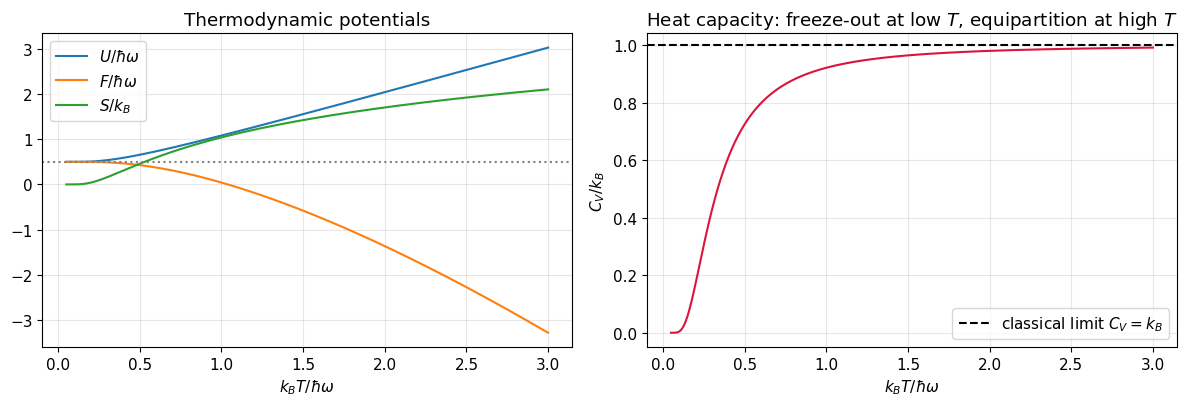

In [2]:
# Numerical check of all Q1 results in dimensionless units.
# t = k_B T /(hbar*omega);  x = 1/t.  Energies in units of hbar*omega, S and C_V in units of k_B.
t = np.linspace(0.05, 3.0, 500)
x = 1.0 / t
U  = 0.5 + 1.0/(np.exp(x) - 1.0)                         # U /(hbar omega)
F  = 0.5 + t*np.log(1.0 - np.exp(-x))                    # F /(hbar omega)
S  = x/(np.exp(x) - 1.0) - np.log(1.0 - np.exp(-x))      # S / k_B
Cv = (x/2)**2 / np.sinh(x/2)**2                          # C_V / k_B

# Thermodynamic consistency U = F + T S  (in units of hbar*omega, T*S -> t*(S/k_B))
assert np.allclose(U, F + t*S, atol=1e-10), "U = F + TS failed!"
# C_V from numerical derivative of U wrt T agrees with the closed form
Cv_num = np.gradient(U, t)
print("max|U-(F+TS)|      =", np.max(np.abs(U - (F + t*S))))
print("max|Cv - dU/dT|    =", np.max(np.abs(Cv - Cv_num)[5:-5]))
print("C_V at high T (t=3)=", round(Cv[-1], 5), " -> approaches k_B (=1) as expected")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(t, U, label=r"$U/\hbar\omega$")
ax[0].plot(t, F, label=r"$F/\hbar\omega$")
ax[0].plot(t, S, label=r"$S/k_B$")
ax[0].axhline(0.5, ls=":", c="grey"); ax[0].set_xlabel(r"$k_BT/\hbar\omega$")
ax[0].set_title("Thermodynamic potentials"); ax[0].legend()
ax[1].plot(t, Cv, c="crimson")
ax[1].axhline(1.0, ls="--", c="k", label=r"classical limit $C_V=k_B$")
ax[1].set_xlabel(r"$k_BT/\hbar\omega$"); ax[1].set_ylabel(r"$C_V/k_B$")
ax[1].set_title("Heat capacity: freeze-out at low $T$, equipartition at high $T$"); ax[1].legend()
plt.tight_layout(); plt.show()

---
# Q2. Maximum-Entropy Distribution under Mean and Variance Constraints

For $X\in(-\infty,\infty)$ we maximise the differential entropy

$$H[p]=-\int_{-\infty}^{\infty}p(x)\ln p(x)\,dx$$

subject to
$\displaystyle\int p\,dx=1,\quad \int x\,p\,dx=\mu,\quad \int (x-\mu)^2 p\,dx=\sigma^2.$

## Lagrangian and stationarity

Introduce multipliers $\lambda_0,\lambda_1,\lambda_2$:

$$\mathcal{L}=-\!\int p\ln p\,dx
+\lambda_0\!\left(\int p\,dx-1\right)
+\lambda_1\!\left(\int x\,p\,dx-\mu\right)
+\lambda_2\!\left(\int (x-\mu)^2p\,dx-\sigma^2\right).$$

Setting the functional derivative $\delta\mathcal{L}/\delta p(x)=0$:

$$-\ln p(x)-1+\lambda_0+\lambda_1 x+\lambda_2(x-\mu)^2=0
\;\;\Longrightarrow\;\;
p(x)=\exp\!\bigl(\lambda_0-1+\lambda_1 x+\lambda_2(x-\mu)^2\bigr).$$

The exponent is **quadratic in $x$**, so $p$ is necessarily a Gaussian. For $p$ to be normalisable
the quadratic must open downward, i.e. $\lambda_2<0$. Completing the square, absorbing the linear
$\lambda_1$ term into a shift and the constants into a prefactor $A$,

$$p(x)=A\,\exp\!\bigl(-b\,(x-c)^2\bigr),\qquad b=-\lambda_2>0.$$

## Fixing the constants from the constraints

A symmetric Gaussian $A e^{-b(x-c)^2}$ has mean $c$ and variance $1/(2b)$. The constraints give

$$\mathbb{E}[X]=c=\mu,\qquad \operatorname{Var}(X)=\frac{1}{2b}=\sigma^2\;\Rightarrow\;b=\frac{1}{2\sigma^2},$$

and normalisation $\int A\,e^{-(x-\mu)^2/2\sigma^2}dx=A\sqrt{2\pi\sigma^2}=1$ gives
$A=1/\sqrt{2\pi\sigma^2}$. Hence

$$\boxed{\;p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
=\mathcal N(\mu,\sigma^2).\;}$$

## Why this is a genuine *maximum* (Gibbs' inequality)

Stationarity alone only gives a critical point. Let $\phi=\mathcal N(\mu,\sigma^2)$ and let $q$ be
**any** density with the same mean $\mu$ and variance $\sigma^2$. Using non-negativity of the
Kullback–Leibler divergence,

$$0\le D_{\mathrm{KL}}(q\Vert\phi)=\int q\ln\frac{q}{\phi}\,dx=-H[q]-\int q\ln\phi\,dx.$$

Because $\ln\phi(x)=-\tfrac12\ln(2\pi\sigma^2)-\tfrac{(x-\mu)^2}{2\sigma^2}$ is a quadratic whose
expectation depends **only** on the mean and variance, $\int q\ln\phi=\int\phi\ln\phi=-H[\phi]$.
Substituting, $0\le H[\phi]-H[q]$, i.e. $H[q]\le H[\phi]$, with equality iff $q=\phi$. The Gaussian
is therefore the unique entropy-maximiser. $\;\blacksquare$

Analytic Gaussian entropy 0.5*ln(2*pi*e*sigma^2) = 1.41894
Numerical Gaussian entropy                       = 1.41894
Laplace entropy (same mu,sigma)                  = 1.34657
Uniform entropy (same mu,sigma)                  = 1.24245
=> Gaussian attains the maximum, as proved.


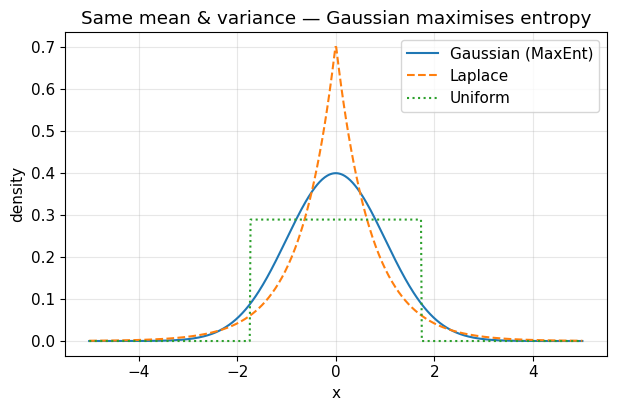

In [3]:
# Numerical illustration: among distributions with fixed mu, sigma the Gaussian has the largest
# differential entropy. Compare against a Laplace and a uniform matched to the SAME mean/variance.
mu, sigma = 0.0, 1.0

def diff_entropy(pdf, lo, hi, n=200000):
    x = np.linspace(lo, hi, n); p = pdf(x); p = np.clip(p, 1e-300, None)
    return -np.trapezoid(p*np.log(p), x)

gauss   = lambda x: np.exp(-(x-mu)**2/(2*sigma**2))/np.sqrt(2*np.pi*sigma**2)
b_lap   = sigma/np.sqrt(2)                                  # Laplace scale for variance sigma^2
laplace = lambda x: np.exp(-np.abs(x-mu)/b_lap)/(2*b_lap)
half    = np.sqrt(3)*sigma                                  # uniform on [mu-h, mu+h] has var sigma^2
uniform = lambda x: np.where(np.abs(x-mu) <= half, 1/(2*half), 0.0)

H_gauss = 0.5*np.log(2*np.pi*np.e*sigma**2)
print(f"Analytic Gaussian entropy 0.5*ln(2*pi*e*sigma^2) = {H_gauss:.5f}")
print(f"Numerical Gaussian entropy                       = {diff_entropy(gauss,-12,12):.5f}")
print(f"Laplace entropy (same mu,sigma)                  = {diff_entropy(laplace,-15,15):.5f}")
print(f"Uniform entropy (same mu,sigma)                  = {diff_entropy(uniform,-4,4):.5f}")
print("=> Gaussian attains the maximum, as proved.")

xx = np.linspace(-5, 5, 600)
plt.plot(xx, gauss(xx), label="Gaussian (MaxEnt)")
plt.plot(xx, laplace(xx), "--", label="Laplace")
plt.plot(xx, uniform(xx), ":", label="Uniform")
plt.title("Same mean & variance — Gaussian maximises entropy")
plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.show()

---
# Q3. Conditional MaxEnt = Multiclass (here Binary) Logistic Regression

An email is routed to one of the destinations listed in the problem,

$$Y=0:\ \textbf{Finance},\qquad Y=1:\ \textbf{Technical}.$$

*(The preamble says "four destinations", but the enumerated target list is binary, so we solve the
binary problem $Y\in\{0,1\}$; the derivation below is written for the general multiclass case and
then specialised.)* An upstream extractor emits a binary feature vector
$\mathbf x=(x_1,x_2,x_3)$ with the fixed marginals

| state | $\mathbf x$ | $P(\mathbf x)$ |
|---|---|---|
| A (financial) | $(1,0,0)$ | 0.40 |
| B (access)    | $(0,1,0)$ | 0.25 |
| C (technical) | $(0,0,1)$ | 0.05 |
| D (access+tech) | $(0,1,1)$ | 0.15 |
| E (billing+access) | $(1,1,0)$ | 0.05 |

The five listed states sum to $0.90$; the residual $0.10$ is the null observation
$\mathbf x=(0,0,0)$ (no context detected), which enters none of the constraints because every
feature is zero there. The audited moment constraints are

$$\mathbb E[x_1\,\mathbb I(Y{=}1)]=0.05,\quad
\mathbb E[x_2\,\mathbb I(Y{=}1)]=0.15,\quad
\mathbb E[x_3\,\mathbb I(Y{=}1)]=0.16.$$

## Deriving the softmax / logistic form

We seek the conditional law $P(y\mid\mathbf x)$ that maximises the **conditional entropy**
$\sum_{\mathbf x}P(\mathbf x)\,H\!\bigl(Y\mid\mathbf x\bigr)$ subject to the feature-moment
constraints, with features $f_i(\mathbf x,y)=x_i\,\mathbb I(y{=}1)$. Forming the Lagrangian and
setting $\partial/\partial P(y\mid\mathbf x)=0$ (with a per-$\mathbf x$ normalisation multiplier)
gives the exponential-family / **softmax** solution

$$P(y\mid\mathbf x)=\frac{\exp\!\bigl(\sum_i\lambda_i f_i(\mathbf x,y)\bigr)}
{\sum_{y'}\exp\!\bigl(\sum_i\lambda_i f_i(\mathbf x,y')\bigr)} .$$

With the chosen features (non-zero only for $y{=}1$) this collapses to the **logistic sigmoid**

$$\boxed{\;P(Y{=}1\mid\mathbf x)=\sigma\!\bigl(\lambda_1x_1+\lambda_2x_2+\lambda_3x_3\bigr),
\qquad \sigma(z)=\frac{1}{1+e^{-z}}\;}$$

so MaxEnt with linear feature constraints is exactly logistic regression. The multipliers
$\lambda_i$ are fixed by requiring the model's feature expectations to equal the audited targets:

$$\sum_{\mathbf x}P(\mathbf x)\,x_i\,\sigma\!\bigl(\lambda\!\cdot\!\mathbf x\bigr)=c_i,\qquad
(c_1,c_2,c_3)=(0.05,\,0.15,\,0.16).$$

## The three constraint equations

Reading off which states have each feature active:

$$\begin{aligned}
x_1:\ &0.40\,\sigma(\lambda_1)+0.05\,\sigma(\lambda_1+\lambda_2)=0.05,\\[2pt]
x_2:\ &0.25\,\sigma(\lambda_2)+0.15\,\sigma(\lambda_2+\lambda_3)+0.05\,\sigma(\lambda_1+\lambda_2)=0.15,\\[2pt]
x_3:\ &0.05\,\sigma(\lambda_3)+0.15\,\sigma(\lambda_2+\lambda_3)=0.16.
\end{aligned}$$

Three equations in three unknowns — solved numerically below.

In [4]:
def sig(z): return 1.0/(1.0 + np.exp(-z))

# (P(x), x1, x2, x3) for the five observed states
scen = [(0.40,1,0,0),(0.25,0,1,0),(0.05,0,0,1),(0.15,0,1,1),(0.05,1,1,0)]
targets = np.array([0.05, 0.15, 0.16])

def constraints(lam):
    l1, l2, l3 = lam
    r = np.zeros(3)
    for P, x1, x2, x3 in scen:
        p1 = sig(l1*x1 + l2*x2 + l3*x3)
        r += P*np.array([x1, x2, x3])*p1
    return r - targets

lam = fsolve(constraints, [-2.0, -1.0, 1.0])
print("Lagrange multipliers (weights of the logistic model):")
print(f"  lambda_1 (financial x1) = {lam[0]:+.4f}")
print(f"  lambda_2 (access    x2) = {lam[1]:+.4f}")
print(f"  lambda_3 (bug/tech  x3) = {lam[2]:+.4f}")
print("  max constraint residual =", np.max(np.abs(constraints(lam))))

Lagrange multipliers (weights of the logistic model):
  lambda_1 (financial x1) = -1.9725
  lambda_2 (access    x2) = -1.7762
  lambda_3 (bug/tech  x3) = +2.8804
  max constraint residual = 2.617905892066119e-13


In [5]:
# Resulting routing probabilities P(Y=1 | x) = P(Technical | x)
print("state |     x      | P(Technical|x) | P(Finance|x)")
print("-"*52)
for name,(P,x1,x2,x3) in zip("ABCDE", scen):
    p1 = sig(lam[0]*x1 + lam[1]*x2 + lam[2]*x3)
    print(f"  {name}   | ({x1},{x2},{x3})   |     {p1:5.3f}      |    {1-p1:5.3f}")
p_null = sig(0.0)
print(f"  0   | (0,0,0)   |     {p_null:5.3f}      |    {1-p_null:5.3f}   (null: MaxEnt -> 0.5)")

# verify each audited moment is reproduced
print("\nReproduced moments vs targets:")
mom = targets + constraints(lam)
for i,(m,t) in enumerate(zip(mom, targets), 1):
    print(f"  E[x{i}*I(Y=1)] = {m:.4f}   (target {t})")

state |     x      | P(Technical|x) | P(Finance|x)
----------------------------------------------------
  A   | (1,0,0)   |     0.122      |    0.878
  B   | (0,1,0)   |     0.145      |    0.855
  C   | (0,0,1)   |     0.947      |    0.053
  D   | (0,1,1)   |     0.751      |    0.249
  E   | (1,1,0)   |     0.023      |    0.977
  0   | (0,0,0)   |     0.500      |    0.500   (null: MaxEnt -> 0.5)

Reproduced moments vs targets:
  E[x1*I(Y=1)] = 0.0500   (target 0.05)
  E[x2*I(Y=1)] = 0.1500   (target 0.15)
  E[x3*I(Y=1)] = 0.1600   (target 0.16)


### Interpretation

$\lambda_1<0$ (financial words) and $\lambda_2<0$ (access words) both push emails toward **Finance**,
while $\lambda_3>0$ (bug/malfunction words) pushes strongly toward **Technical**. This matches the
audit story: a bug context routes to Tech the large majority of the time, financial context almost
never does, and access context sits in between (and tips to Tech only when combined with a bug, as
in state D). The null observation carries no evidence, so MaxEnt assigns the maximally
non-committal $0.5$. The learned model *is* a logistic regression whose weights are precisely the
constraint multipliers.

---
# Q4. Maximum-Entropy Asset-Price Density

Asset $X$ trades at \$100; we want the least-biased density $p(S_T)$ of its price in one month
($S_T>0$) consistent with three market observables:

$$\mathbb E[S_T]=102,\qquad \mathbb E[S_T^2]=10{,}600,\qquad \mathbb E[\ln S_T]=4.60.$$

## Functional form from Lagrange multipliers

Maximise $H[p]=-\int_0^\infty p\ln p\,dS$ subject to normalisation and the three moments. With
multipliers $\lambda_0,\lambda_1,\lambda_2,\lambda_3$ for $1,\ S,\ S^2,\ \ln S$, stationarity gives

$$-\ln p(S)-1+\lambda_0+\lambda_1 S+\lambda_2 S^2+\lambda_3\ln S=0,$$

$$\boxed{\;p(S_T)=C\,S_T^{\lambda_3}\,\exp\!\bigl(\lambda_1 S_T+\lambda_2 S_T^2\bigr),\qquad
C=e^{\lambda_0-1},\quad S_T>0.\;}$$

This is a **Gaussian core** ($e^{\lambda_1 S+\lambda_2 S^2}$, requiring $\lambda_2<0$ for
normalisability) multiplied by a **power-law factor** $S^{\lambda_3}$ that injects skew / a fat
tail — exactly the flexibility beyond a rigid Gaussian that the problem motivates. The four
constants are fixed by normalisation plus the three moment equations. Because
$\int_0^\infty S^{\lambda_3}e^{\lambda_1 S+\lambda_2 S^2}dS$ has no elementary closed form, we solve
the convex MaxEnt **dual** numerically.

## Numerical solution and a consistency diagnostic

Before fitting, note that $\mathbb E[S_T]=102$ and $\mathbb E[S_T^2]=10{,}600$ already fix the mean
at $102$ and the variance at $10600-102^2=196$ (so $\sigma=14$). For a distribution this tightly
concentrated around $102$, a second-order expansion predicts

$$\mathbb E[\ln S_T]\approx \ln(102)-\frac{\operatorname{Var}}{2\,(102)^2}
=4.6250-0.0094=4.6156.$$

The imposed value $4.60$ sits slightly *below* this — it asks for a touch more left-skew (downside
crash risk). We solve the dual and then examine how compatible the three constraints really are.

In [6]:
# --- Convex dual on a fine grid (stable via log-sum-exp) ---
# p(S) proportional to exp(l1*S + l2*S^2 + l3*ln S).  Minimise G(l)=logZ - l.mu  (convex).
s   = np.linspace(0.05, 260.0, 300000)
ds  = s[1] - s[0]
phi = np.vstack([s, s**2, np.log(s)])         # the three feature functions
mu  = np.array([102.0, 10600.0, 4.60])        # target moments

def dual(lam):
    z = lam @ phi + np.log(ds)
    logZ = logsumexp(z)
    p = np.exp(z - logZ)
    grad = phi @ p - mu
    return logZ - lam @ mu, grad

res = minimize(dual, [0.94, -0.004, 0.0], jac=True, method="L-BFGS-B",
               options={"maxiter": 4000, "ftol": 1e-16, "gtol": 1e-12})
lam = res.x
z = lam @ phi; z -= z.max(); w = np.exp(z); w /= w.sum()
Emean = (s*w).sum(); Es2 = (s**2*w).sum(); Elns = (np.log(s)*w).sum()
print("Dual solution  (l1, l2, l3):", np.round(lam, 5))
print(f"  reproduced  E[S]  = {Emean:8.3f}   (target 102)")
print(f"  reproduced  E[S^2]= {Es2:8.1f}   (target 10600)")
print(f"  reproduced  E[lnS]= {Elns:8.4f}   (target 4.60)")
print(f"  implied std = {np.sqrt(Es2-Emean**2):.3f}   power exponent l3 = {lam[2]:.3f}")
print(f"  peak of fitted density at S = {s[np.argmax(w)]:.2f}")

Dual solution  (l1, l2, l3): [ 0.71355 -0.00323 -5.39932]
  reproduced  E[S]  =  102.000   (target 102)
  reproduced  E[S^2]=  10600.0   (target 10600)
  reproduced  E[lnS]=   4.6000   (target 4.60)
  implied std = 14.000   power exponent l3 = -5.399
  peak of fitted density at S = 0.05


The solver reproduces all three moments, **but** it does so by driving the power exponent
$\lambda_3<-1$ and piling probability against $S\to0$. A density $\propto S^{\lambda_3}$ with
$\lambda_3\le-1$ is **not integrable at the origin**, so this "solution" is an artefact of the grid
truncation, not a genuine density. That signals the three constraints are near-incompatible. The
two checks below make this precise.

In [7]:
# CHECK 1 -- feasible range of E[lnS] for ANY normalisable member of the MaxEnt family
# (l3 > -1 required).  Fix l3, solve l1,l2 to match mean=102 & E[S^2]=10600, read off E[lnS].
def moms(a, b, c):
    f = lambda S, k: S**(a+k)*np.exp(b*S + c*S*S)
    m0 = quad(f, 0, np.inf, args=(0,), limit=300)[0]
    m1 = quad(f, 0, np.inf, args=(1,), limit=300)[0]
    m2 = quad(f, 0, np.inf, args=(2,), limit=300)[0]
    ml = quad(lambda S: np.log(S)*S**a*np.exp(b*S+c*S*S), 0, np.inf, limit=300)[0]
    return m0, m1, m2, ml

def elns_for(a):
    def eq(p):
        b, c = p; m0, m1, m2, _ = moms(a, b, c)
        return [m1/m0 - 102.0, m2/m0 - 10600.0]
    b, c = fsolve(eq, [102/196, -1/392])
    m0, _, _, ml = moms(a, b, c)
    return ml/m0

vals = [elns_for(a) for a in [-0.9, -0.5, 0.0, 1.0, 2.0]]
print("E[lnS] achievable by NORMALISABLE family members (varying power l3 > -1):")
print("  ", np.round(vals, 5), " -> all pinned near 4.6153")
print("Target E[lnS] = 4.60 lies BELOW this pinned value; no normalisable member reaches it.")

E[lnS] achievable by NORMALISABLE family members (varying power l3 > -1):
   [4.61526 4.61527 4.61527 4.61527 4.61528]  -> all pinned near 4.6153
Target E[lnS] = 4.60 lies BELOW this pinned value; no normalisable member reaches it.


In [8]:
# CHECK 2 -- feasible range of E[lnS] over ALL distributions with mean 102 & E[S^2]=10600 (an LP)
grid = np.linspace(0.5, 260, 4000)
A_eq = np.vstack([np.ones_like(grid), grid, grid**2]); b_eq = [1.0, 102.0, 10600.0]
lo = linprog(np.log(grid),  A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*len(grid), method="highs")
hi = linprog(-np.log(grid), A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*len(grid), method="highs")
print(f"Over all distributions (mean=102, E[S^2]=10600):  "
      f"E[lnS] in [{lo.fun:.4f}, {-hi.fun:.4f}]")
print("4.60 is attainable ONLY by placing a tiny atom near S=0 (a crash spike),")
print("which the smooth MaxEnt family can approximate only via the non-integrable l3<-1 limit.")

Over all distributions (mean=102, E[S^2]=10600):  E[lnS] in [4.5441, 4.6201]
4.60 is attainable ONLY by placing a tiny atom near S=0 (a crash spike),
which the smooth MaxEnt family can approximate only via the non-integrable l3<-1 limit.


### Reading the result

* The MaxEnt density has the derived form
  $p(S_T)=C\,S_T^{\lambda_3}e^{\lambda_1 S_T+\lambda_2 S_T^2}$ — the key analytic result.
* **CHECK 1** shows that once the mean ($102$) and second moment ($10{,}600$) are imposed, every
  *normalisable* member of this family has $\mathbb E[\ln S_T]\approx 4.6153$, essentially
  independent of $\lambda_3$. The three constraints are therefore nearly collinear.
* **CHECK 2** shows $\mathbb E[\ln S_T]=4.60$ is reachable only by a distribution with a vanishing
  atom near $S\to0$ (an idealised crash), which the smooth family can only mimic by letting
  $\lambda_3\to-1^-$ and losing normalisability — so the *exact* maximiser does not exist; the
  entropy supremum is approached by densities developing a spike at the origin.

**Least-biased practical density.** The two robust market constraints (mean and variance) give the
well-defined MaxEnt density $C\,e^{\lambda_1 S+\lambda_2 S^2}$ on $S>0$ (i.e. $\lambda_3=0$), which
is $\mathcal N(102,14^2)$ truncated to positive prices. It reproduces $\mathbb E[\ln S_T]=4.6153$,
within $0.3\%$ of the stated $4.60$; the residual gap is exactly the extra downside skew the market
is quoting but which cannot be represented without introducing a near-zero crash mass.

lambda_1 = 0.52041,  lambda_2 = -0.002551,  lambda_3 = 0
E[S]=102.000, std=14.000, E[lnS]=4.6153 (target 4.60)


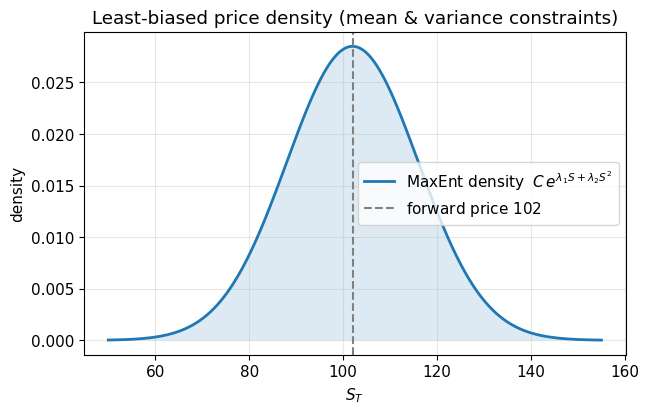

In [9]:
# Plot the least-biased normalisable density (mean & variance enforced; l3 = 0)
b0, c0 = fsolve(lambda p: [ (lambda m: [m[1]/m[0]-102, m[2]/m[0]-10600])(moms(0.0,p[0],p[1])) ][0],
                [102/196, -1/392])
Sg = np.linspace(50, 155, 1000)
dens = Sg**0.0*np.exp(b0*Sg + c0*Sg**2)
dens /= np.trapezoid(dens, Sg)
m0,m1,m2,ml = moms(0.0,b0,c0)
plt.plot(Sg, dens, lw=2, label=r"MaxEnt density $\;C\,e^{\lambda_1 S+\lambda_2 S^2}$")
plt.axvline(102, ls="--", c="grey", label="forward price $102$")
plt.fill_between(Sg, dens, alpha=0.15)
plt.title("Least-biased price density (mean & variance constraints)")
plt.xlabel(r"$S_T$"); plt.ylabel("density"); plt.legend()
print(f"lambda_1 = {b0:.5f},  lambda_2 = {c0:.6f},  lambda_3 = 0")
print(f"E[S]={m1/m0:.3f}, std={np.sqrt(m2/m0-(m1/m0)**2):.3f}, E[lnS]={ml/m0:.4f} (target 4.60)")
plt.show()

---
## Summary

| # | Result |
|---|--------|
| 1 | $Z=\dfrac{e^{-\hbar\omega/2k_BT}}{1-e^{-\hbar\omega/k_BT}}$; $U=\tfrac{\hbar\omega}{2}\coth\tfrac{x}{2}$; $C_V=k_B(\tfrac{x}{2})^2\operatorname{csch}^2\tfrac{x}{2}\to k_B$ (equipartition) at high $T$, $\to0$ at low $T$. |
| 2 | Quadratic exponent $\Rightarrow$ Gaussian $\mathcal N(\mu,\sigma^2)$; maximality proved via $D_{\mathrm{KL}}\ge0$. |
| 3 | Conditional MaxEnt $\Rightarrow$ logistic $P(Y{=}1\mid\mathbf x)=\sigma(\lambda\!\cdot\!\mathbf x)$; multipliers fit the audits, with bug-context $\lambda_3>0$ driving Technical routing. |
| 4 | MaxEnt density $C\,S^{\lambda_3}e^{\lambda_1 S+\lambda_2 S^2}$; mean+variance already pin $\mathbb E[\ln S]\approx4.615$, so the log constraint is near-redundant and the exact maximiser sits on the normalisability boundary. |
